<a href="https://colab.research.google.com/github/RAseng77/computer_vision_study/blob/main/%EC%BB%B4%ED%93%A8%ED%84%B0%EA%B8%B0%EB%B3%B8_%EA%B8%B0%EC%B4%88/%EC%98%81%EC%83%81%EB%B0%9D%EA%B8%B0_%EC%B0%A8%EC%9D%B4%EC%97%90_%EB%94%B0%EB%A5%B8%EB%B6%84%EB%A5%98(%EA%B3%B5%EB%B6%80).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 🔧 완전 고정: imgaug + numpy 1.x
!pip uninstall -y numpy imgaug
!pip install -q "numpy<2.0" "imgaug==0.4.0"

# 🔁 런타임 재시작 (중요!)
import os, signal
os.kill(os.getpid(), signal.SIGKILL)

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 12.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [1]:
import numpy as np
print("NumPy:", np.__version__)
from imgaug import augmenters as iaa
import imgaug as ia
print("imgaug:", ia.__version__)

NumPy: 1.26.4
imgaug: 0.4.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 압축 풀기
!unzip "/content/drive/MyDrive/file/영상밝기.zip" -d /content/brightness_dataset

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: /content/brightness_dataset/5/train/normal/ADE_train_00008961.jpg  
  inflating: /content/brightness_dataset/5/train/lowlight/2015_06791.jpg  
  inflating: /content/brightness_dataset/5/train/normal/ADE_train_00010803.jpg  
  inflating: /content/brightness_dataset/5/train/normal/ADE_train_00001520.jpg  
  inflating: /content/brightness_dataset/5/train/normal/ADE_train_00005842.jpg  
  inflating: /content/brightness_dataset/5/train/normal/ADE_train_00004821.jpg  
  inflating: /content/brightness_dataset/5/train/normal/ADE_train_00011920.jpg  
  inflating: /content/brightness_dataset/5/train/normal/ADE_train_00007474.jpg  
  inflating: /content/brightness_dataset/5/train/normal/ADE_train_00012417.jpg  
  inflating: /content/brightness_dataset/5/train/normal/ADE_train_00009253.jpg  
  inflating: /content/brightness_dataset/5/train/lowlight/2015_06546.jpg  
  inflating: /content/brightness_dataset/5/train/normal/ADE_train_00001234.jpg  
  in

In [5]:
!ls /content/brightness_dataset/5/train

lowlight  normal


In [6]:
# 필수 Package import
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models

import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

In [8]:
device

device(type='cuda')

In [9]:
print('Device:', device)
print('Count of using GPUs: ',torch.cuda.device_count())

Device: cuda
Count of using GPUs:  1


In [10]:
# 이미지를 출력하는 함수
def display_images(image_paths, title, max_images=4):
  """지정된 경로의 이미지를 최대 4개까지 출력합니다."""
  plt.figure(figsize=(12, 3))
  for i, image_path in enumerate(image_paths[:max_images]):
    img = plt.imread(image_path)
    plt.subplot(1, max_images, i+1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
  plt.show()

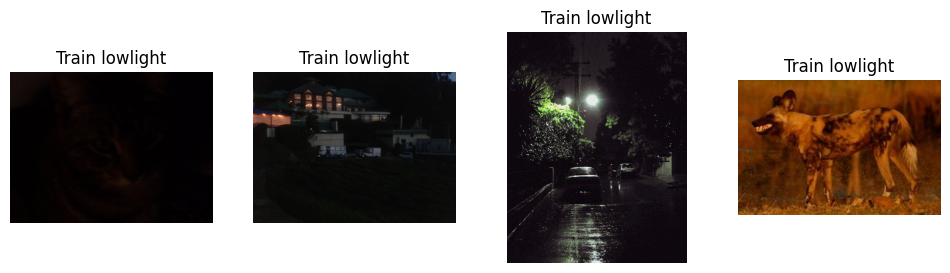

Train lowlight 총 이미지 수: 3686


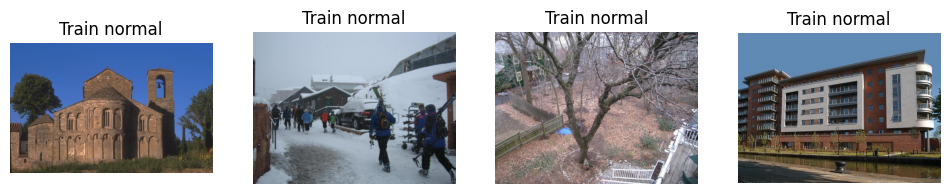

Train normal 총 이미지 수: 3846


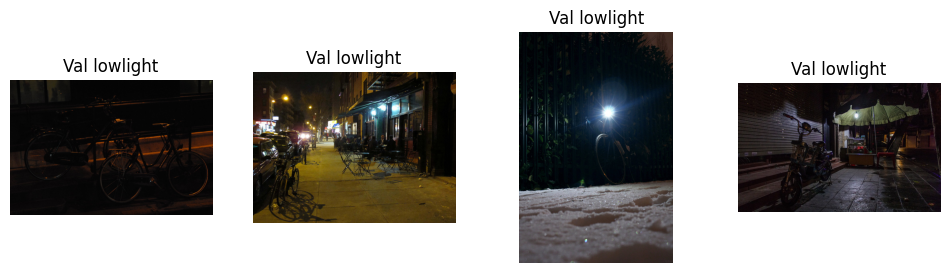

Val lowlight 총 이미지 수: 652


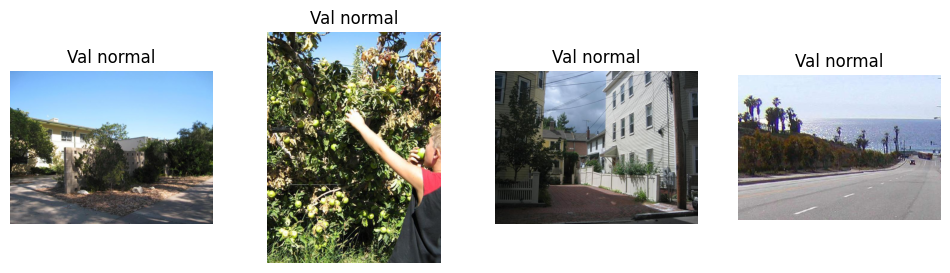

Val normal 총 이미지 수: 689


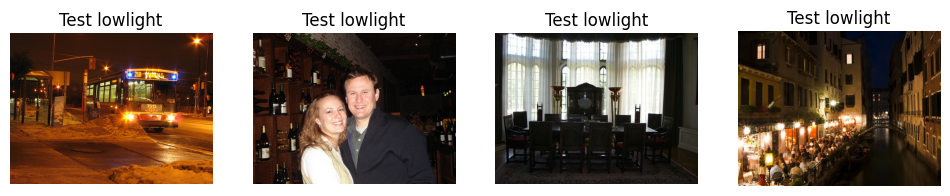

Test lowlight 총 이미지 수: 50


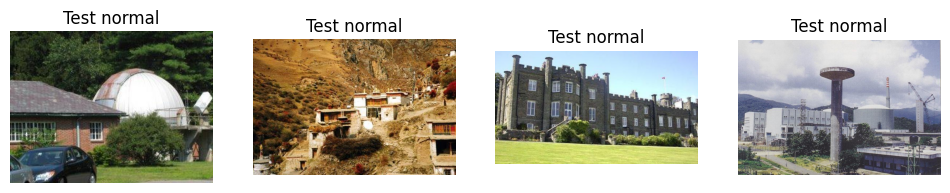

Test normal 총 이미지 수: 50


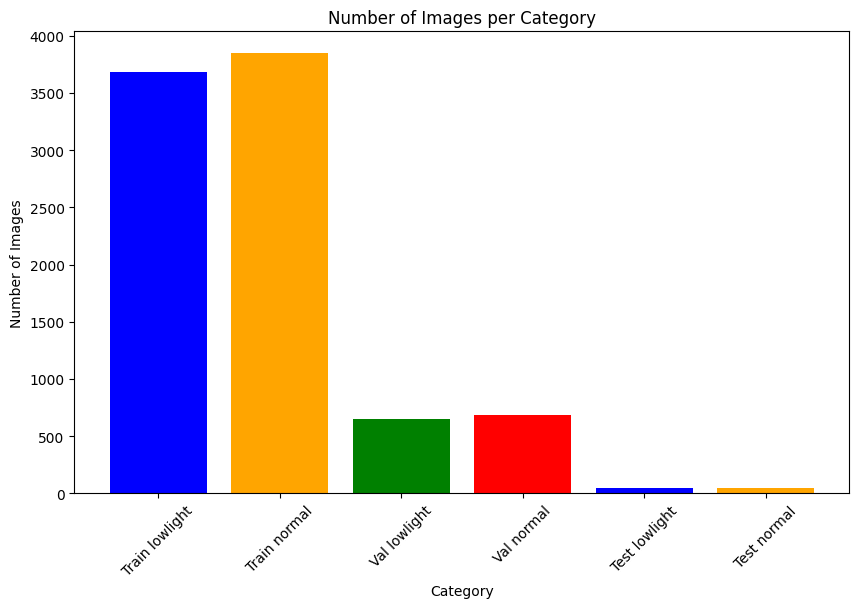

In [13]:
# 이미지와 바 그래프 출력
categories = ['Train lowlight', 'Train normal', 'Val lowlight', 'Val normal', 'Test lowlight', 'Test normal']

for category in categories:
  image_paths = glob.glob(f'/content/brightness_dataset/5/{category.lower().replace(" ","/")}/*')
  display_images(image_paths, category)
  print(f"{category} 총 이미지 수: {len(image_paths)}")

# 바 그래프 생성
plt.figure(figsize=(10, 6))
plt.bar(categories, [len(glob.glob(f'/content/brightness_dataset/5/{category.lower().replace(" ", "/")}/*')) for category in categories], color=['blue', 'orange', 'green', 'red'])
plt.title('Number of Images per Category')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

In [14]:
from imgaug import augmenters as iaa
import imgaug as ia

# imgaug를 사용한 커스텀 데이터셋 정의
class ImgAugTransform:
  def __init__(self):
    self.aug = iaa.Sequential([
        iaa.Fliplr(0.5), # 50% 확률로 좌우 반전
        iaa.Affine(rotate=(-20, 20), mode='symmetric'), # -20도에서 20도 사이로 회전
    ])

  def __call__(self, img):
    img = np.array(img)
    return self.aug.augment_image(img)

# imgaug를 사용한 커스텀 데이터셋 정의 (light 변화 추가)
class ImgAugTransform_Light:
  def __init__(self):
    self.aug = iaa.Sequential([
        iaa.Fliplr(0.5), # 50% 확률로 좌우 반전
        iaa.Affine(rotate=(-20, 20), mode='symmetric'), # -20도에서 20도 사이로 회전
        iaa.Multiply((0.8, 1.2)), # 밝기 변화, 0.8에서 1.2 범위의 랜덤한 값을 곱함
        iaa.LinearContrast((0.75, 1.5)), # 대비 조정
        iaa.HistogramEqualization(),
        iaa.CLAHE(),
        iaa.GammaContrast((0.5, 2.0)), # Gamma 조정, 0.5에서 2.0 사이의 값으로 조정
    ])

  def __call__(self, img):
    img = np.array(img)
    return self.aug.augment_image(img)

# 커스텀 데이터셋 클래스
class CustomDataset(ImageFolder):
  def __init__(self, root, imgaug=None, transform=None):
    super(CustomDataset, self).__init__(root, transform=transform)
    self.imgaug_transform = imgaug # imgaug 매개변수를 직접 저장

  def __getitem__(self, index):
    path, target = self.samples[index]
    img = self.loader(path)

    # imgaug 증강 적용
    if self.imgaug_transform is not None:
      img = self.imgaug_transform(img)
      # imgaug는 numpy 배열을 반환하므로, PIL Image로 다시 변환
      img = Image.fromarray(img)

    # ToTensor 및 Normalizae 적용
    if self.transform is not None:
      img = self.transform(img)

    return img, target

In [15]:
# PyTorch transforms에서 ToTensor 및 Normalize만 적용
pytorch_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # 이미지 크기 조정
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [16]:
from torch.utils.data import SubsetRandomSampler

# 데이터셋의 인덱스를 생성
num_of_train = 7532
num_of_val = 1341
train_indices = list(range(num_of_train))
val_indices = list(range(num_of_val))

# 2500개의 무작위 샘플 선택
np.random.shuffle(train_indices)
train_subset_indices = train_indices[:2500]

np.random.shuffle(val_indices)
val_subset_indices = val_indices[:200]

# 사용자 정의 Sampler 생성
train_sampler = SubsetRandomSampler(train_subset_indices)
val_sampler = SubsetRandomSampler(val_subset_indices)

In [17]:
# 데이터셋 및 데이터 로더 초기화
train_dataset = CustomDataset('/content/brightness_dataset/5/train', imgaug=ImgAugTransform(), transform=pytorch_transforms)
val_dataset = CustomDataset('/content/brightness_dataset/5/val', imgaug=None, transform=pytorch_transforms)

train_loader = DataLoader(train_dataset, batch_size=16, sampler=train_sampler)
val_loader = DataLoader(val_dataset, batch_size=16, sampler=val_sampler)

In [18]:
# DataLoader에서 샘플을 이미지를 load해 show하는 함수
def imshow(img, size=(20, 20), mean=(0.5, 0.5, 0.5), std=(0.5,0.5,0.5)):
  # 텐서를 넘파이 배열로 바꾸고, 차원 순서를 (C, H, W) -> (H, W, C)로 변환
  img = img.numpy().transpose((1, 2, 0))

  # mean과 std를 numy 배열로 변환 (정규화 해제를 위해 필요)
  mean = np.array(mean)
  std = np.array(std)

  # 정규화를 원래 값으로 되돌림: (정규화된 값 * 표준편차) + 평균
  img = std * img + mean

  # 값이 0보다 작거나 1보다 큰 경우 잘라서 [0,1] 범위로 맞춤
  img = np.clip(img, 0, 1)

  # 그래프 크기를 지정
  plt.figure(figsize=size)

  # 이미지를 화면에 표시
  plt.imshow(img)

  plt.axis('off')
  plt.show()

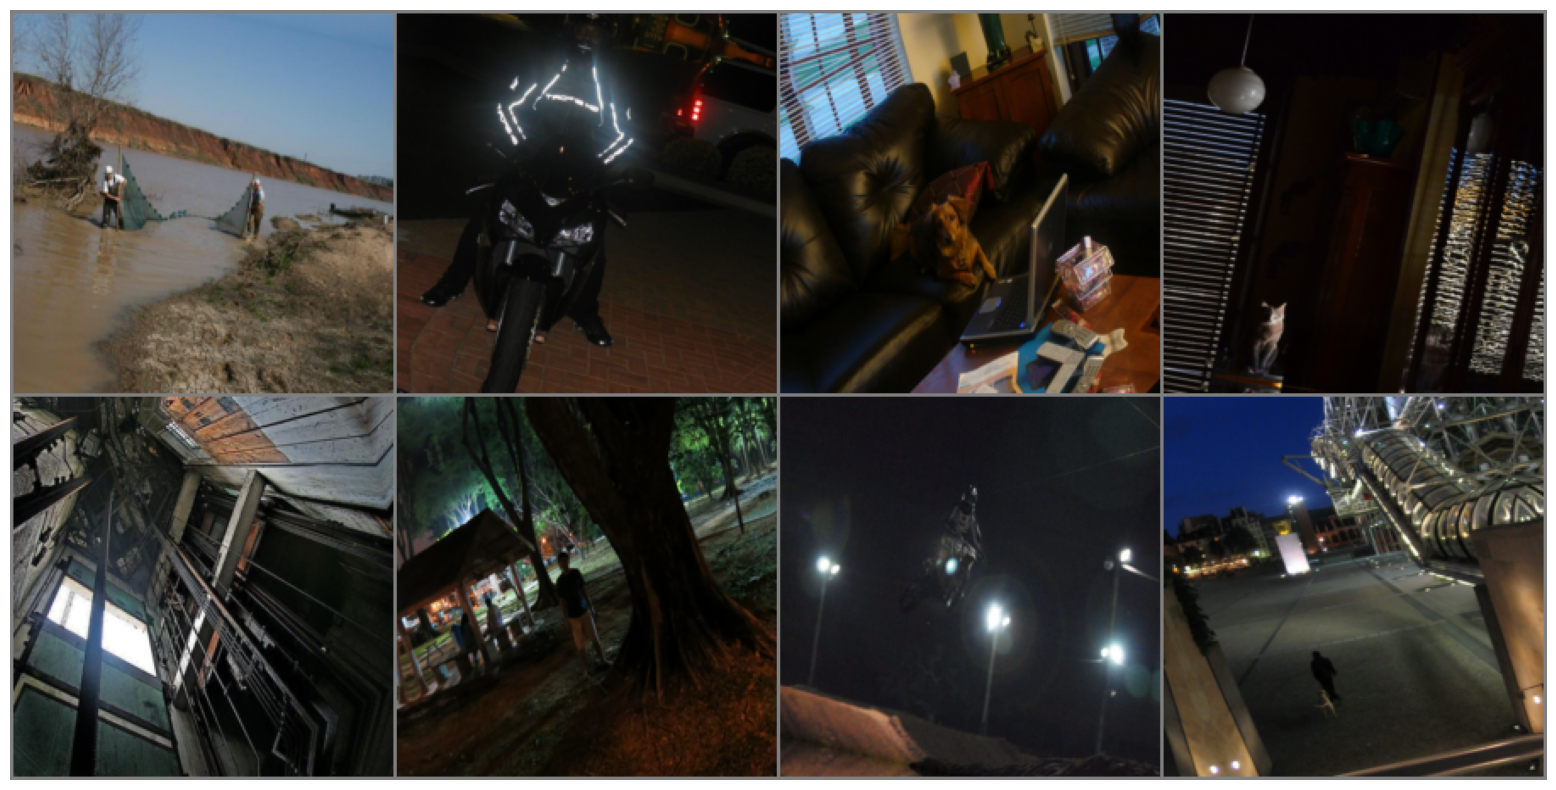

In [19]:
# DataLoader를 이용하여 배치 데이터 가져오기
dataiter = iter(train_loader)   # train_loader는 반복 가능한 객체(이터레이터)
images, _ = next(dataiter)      # 첫 번째 배치 꺼내오기 (이미지와 라벨 반환, 라벨은 _로 무시)

# 이미지 그리드 생성 및 시각화, nrow를 조정하여 한 줄에 표시되는 이미지의 수 조정
# make_grid: 여러 이미지를 하나의 큰 격자(grid) 이미지로 합쳐줌
# images[:8]: 배치에서 앞의 8개 이미지만 선택
# nrow=4: 한 줄(row)에 4개씩 배치
imshow(make_grid(images[:8], nrow=4), size=(20, 10))

In [20]:
# Resnet 모델 로드 및 네트워크 구조 확인
net = models.resnet50(pretrained=True)
net

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [21]:
# 모델의 모든 파라미터를 고정
for param in net.parameters():
  param.requires_grad = False

In [22]:
# classifier의 마지막 레이어를 Binary Classification Task에 맞게 교체하고, 이 레이어의 파라미터는 학습 가능하도록 설정
net.fc = nn.Linear(2048, 2)
net.fc.requires_grad = True

In [24]:
net = net.to(device)

In [25]:
# 손실 함수
criterion = nn.CrossEntropyLoss()

In [26]:
def train_model(optimizer_name, net, train_loader, val_loader, criterion, num_epochs=30):
  # optimizer 설정
  if optimizer_name == 'SGD':
    optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
  elif optimizer_name == 'Adam':
    optimizer = optim.Adam(net.parameters(), lr=0.001, betas=(0.9, 0.999))
  elif optimizer_name == 'RAdam':
    optimizer = optim.RAdam(net.parameters(), lr=0.001, betas=(0.9, 0.999))
  else:
    raise ValueError(f"Unsupported optimizer: {optimizer_name}")

  # 학습/검증 손실과 검증 정확도를 저장할 리스트
  train_losses = []
  val_losses = []
  val_accuracies = []

  for epoch in range(num_epochs):
    net.train() # 모델을 학습 모드로 설정
    running_loss = 0.0 # 에포크 동안의 학습 손실 합계
    for i, data in enumerate(train_loader):
      inputs, labels = data     # 배치 데이터 분리
      inputs, labels = inputs.to(device), labels.to(device) # GPU/CPU로 데이터 이동

      optimizer.zero_grad() # 이전 배치의 기울기 초기화
      outputs = net(inputs) # 순전파
      loss = criterion(outputs, labels) # 손실 계산
      loss.backward() # 역전파
      optimizer.step() # 옵티마이저로 파라미터 업데이트

      running_loss += loss.item() # 배치 손실을 누적

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)


    val_loss = 0.0
    net.eval() # 모델을 평가 모드로 설정
    correct = 0
    total = 0

    with torch.no_grad():
      for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)

        # 로짓(logit)을 소프트맥스로 변환 -> 확률값
        probabilities = F.softmax(outputs, dim=1)
        # 가장 높은 확률을 가진 클래스 선택 (예측값)
        _, predicted = torch.max(probabilities, 1)

        # 전체 샘플 수 / 정답 맞춘 수 누적
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 검증 손실 계산
        loss = criterion(outputs,labels)
        val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)

    print(f'[{optimizer_name}] Epoch {epoch + 1}, '
              f'Train Loss: {train_loss:.6f}, '
              f'Val Loss: {val_loss:.6f}, '
              f'Validation Accuracy: {val_accuracy:.2f}%')

  return train_losses, val_losses, val_accuracies

In [27]:
train_losses_default_aug, val_losses_default_aug, val_accuracies_default_aug = train_model('RAdam', net, train_loader, val_loader, criterion)

[RAdam] Epoch 1, Train Loss: 0.420956, Val Loss: 0.227160, Validation Accuracy: 96.50%
[RAdam] Epoch 2, Train Loss: 0.164613, Val Loss: 0.149156, Validation Accuracy: 95.00%
[RAdam] Epoch 3, Train Loss: 0.122406, Val Loss: 0.142575, Validation Accuracy: 95.00%
[RAdam] Epoch 4, Train Loss: 0.111304, Val Loss: 0.093482, Validation Accuracy: 98.00%
[RAdam] Epoch 5, Train Loss: 0.102525, Val Loss: 0.089040, Validation Accuracy: 97.00%
[RAdam] Epoch 6, Train Loss: 0.081323, Val Loss: 0.068766, Validation Accuracy: 97.50%
[RAdam] Epoch 7, Train Loss: 0.090803, Val Loss: 0.080332, Validation Accuracy: 97.00%
[RAdam] Epoch 8, Train Loss: 0.095177, Val Loss: 0.062032, Validation Accuracy: 98.00%
[RAdam] Epoch 9, Train Loss: 0.084017, Val Loss: 0.051584, Validation Accuracy: 98.00%
[RAdam] Epoch 10, Train Loss: 0.062881, Val Loss: 0.054481, Validation Accuracy: 98.00%
[RAdam] Epoch 11, Train Loss: 0.060956, Val Loss: 0.059533, Validation Accuracy: 97.50%
[RAdam] Epoch 12, Train Loss: 0.089140, V

In [28]:
# 데이터셋 및 데이터 로더 초기화
train_dataset = CustomDataset('/content/brightness_dataset/5/train', imgaug=ImgAugTransform_Light(), transform=pytorch_transforms)
train_loader = DataLoader(dataset=train_dataset, batch_size=16, sampler=train_sampler)

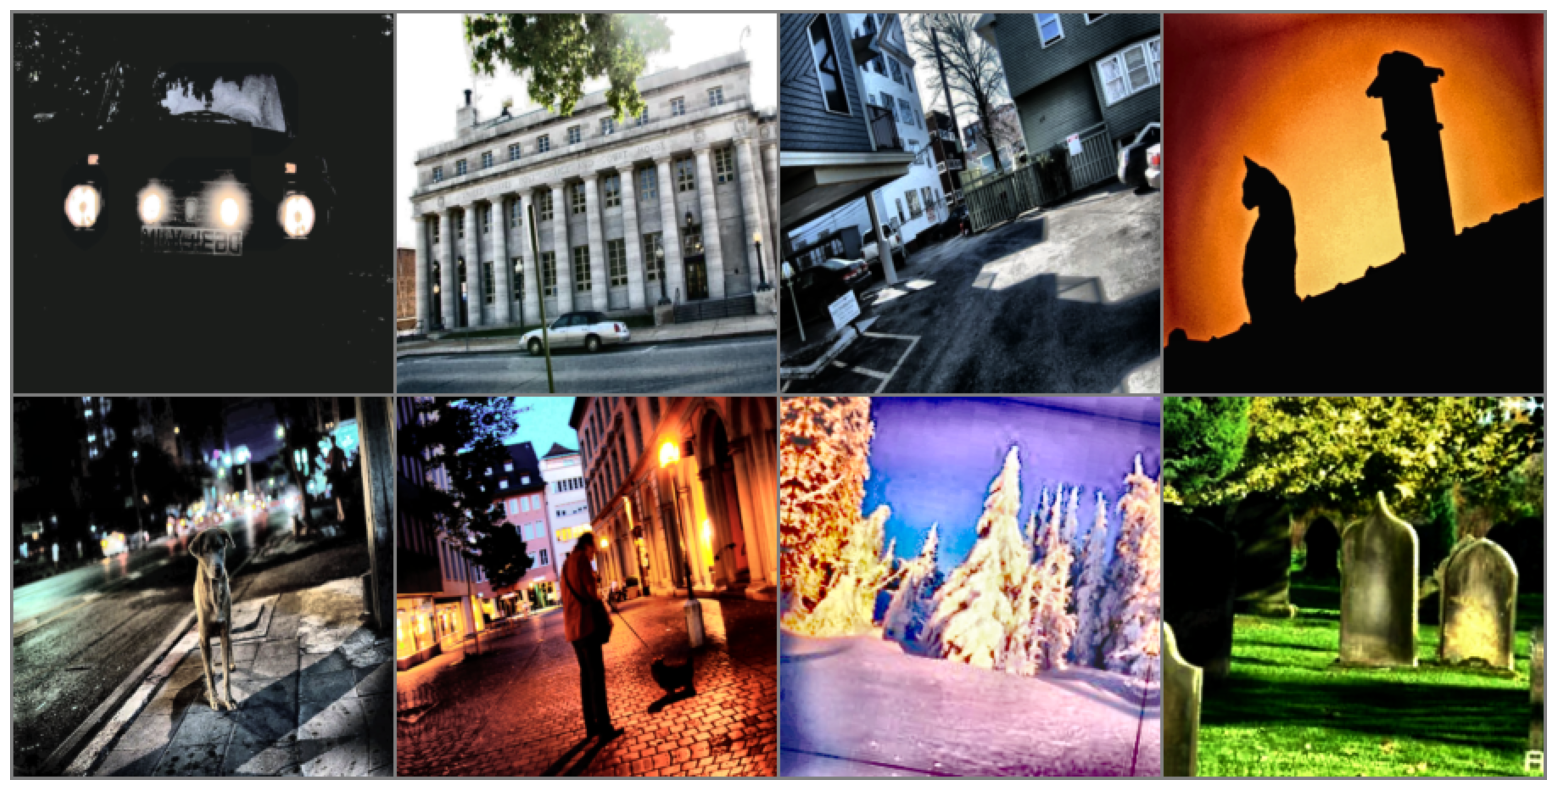

In [29]:
# DataLoader를 이용하여 배치 데이터 가져오기
dataiter = iter(train_loader)
images, _ = next(dataiter)

# 이미지 그리드 생성 및 시각화, nrow를 조정하여 한 줄에 표시되는 이미지의 수 조정
imshow(make_grid(images[:8], nrow=4), size=(20, 10))

In [30]:
# 초기화
net = models.resnet50(pretrained=True)
for param in net.parameters():
  param.requires_grad = False
net.fc = nn.Linear(2048, 2)
net.fc.requires_grad = True

net = net.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [31]:
train_losses_light_aug, val_losses_light_aug, val_accuracies_light_aug = train_model('RAdam', net, train_loader, val_loader, criterion)

[RAdam] Epoch 1, Train Loss: 0.487241, Val Loss: 0.306950, Validation Accuracy: 90.50%
[RAdam] Epoch 2, Train Loss: 0.235496, Val Loss: 0.184651, Validation Accuracy: 93.00%
[RAdam] Epoch 3, Train Loss: 0.188915, Val Loss: 0.167028, Validation Accuracy: 94.00%
[RAdam] Epoch 4, Train Loss: 0.153721, Val Loss: 0.135994, Validation Accuracy: 95.00%
[RAdam] Epoch 5, Train Loss: 0.135831, Val Loss: 0.128792, Validation Accuracy: 95.00%
[RAdam] Epoch 6, Train Loss: 0.117745, Val Loss: 0.133952, Validation Accuracy: 95.50%
[RAdam] Epoch 7, Train Loss: 0.120758, Val Loss: 0.106859, Validation Accuracy: 96.50%
[RAdam] Epoch 8, Train Loss: 0.125303, Val Loss: 0.111948, Validation Accuracy: 95.50%
[RAdam] Epoch 9, Train Loss: 0.128788, Val Loss: 0.144072, Validation Accuracy: 95.00%
[RAdam] Epoch 10, Train Loss: 0.128835, Val Loss: 0.125235, Validation Accuracy: 95.00%
[RAdam] Epoch 11, Train Loss: 0.119846, Val Loss: 0.160096, Validation Accuracy: 94.50%
[RAdam] Epoch 12, Train Loss: 0.175842, V

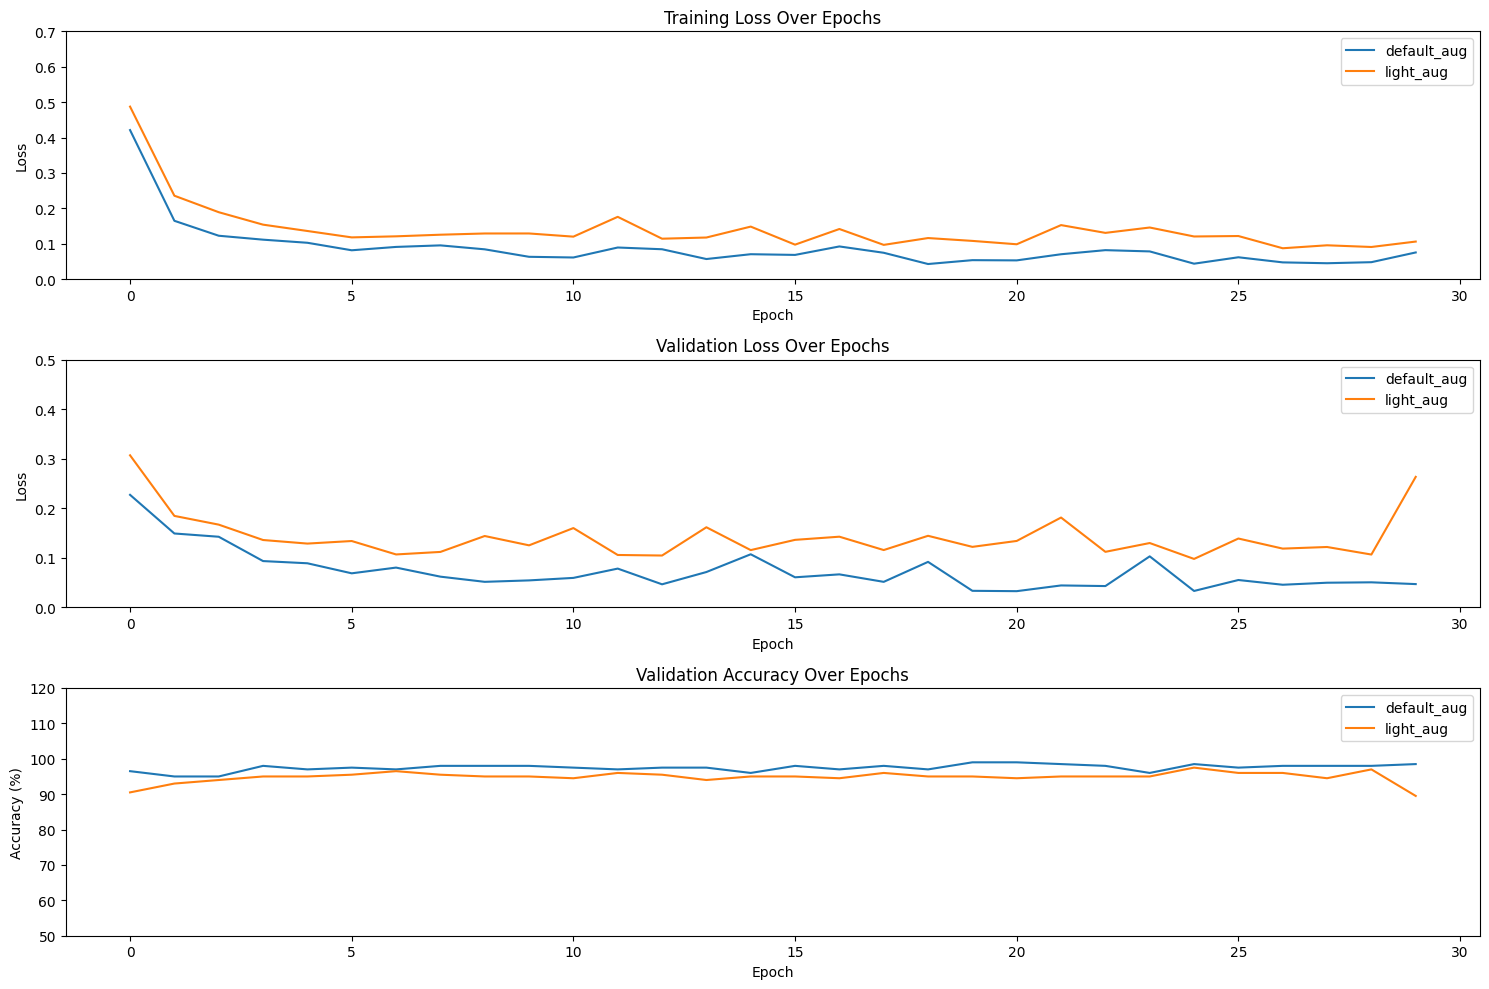

In [32]:
# 학습 손실과 검증 정확도 그래프 그리기
plt.figure(figsize=(15, 10))

# 학습 손실 그래프
plt.subplot(3, 1, 1)  # 3행 1열의 첫 번째 위치
plt.plot(train_losses_default_aug, label='default_aug')
plt.plot(train_losses_light_aug, label='light_aug')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.ylim(0, 0.7)

# 검증 손실 그래프
plt.subplot(3, 1, 2)  # 3행 1열의 두 번째 위치
plt.plot(val_losses_default_aug, label='default_aug')
plt.plot(val_losses_light_aug, label='light_aug')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Over Epochs')
plt.legend()
plt.ylim(0, 0.5)

# 검증 정확도 그래프
plt.subplot(3, 1, 3)  # 3행 1열의 세 번째 위치
plt.plot(val_accuracies_default_aug, label='default_aug')
plt.plot(val_accuracies_light_aug, label='light_aug')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.ylim(50, 120)  # y축 범위를 0에서 100까지 설정

plt.tight_layout()
plt.show()

In [33]:
# Image load 및 tensor로 변환
def load_and_transform_image(image_path, transform):
  image = Image.open(image_path).convert('RGB')
  return transform(image).unsqueeze(0).to(device) # 이미지를 모델에 맞게 변환하고 배치 차원 추가

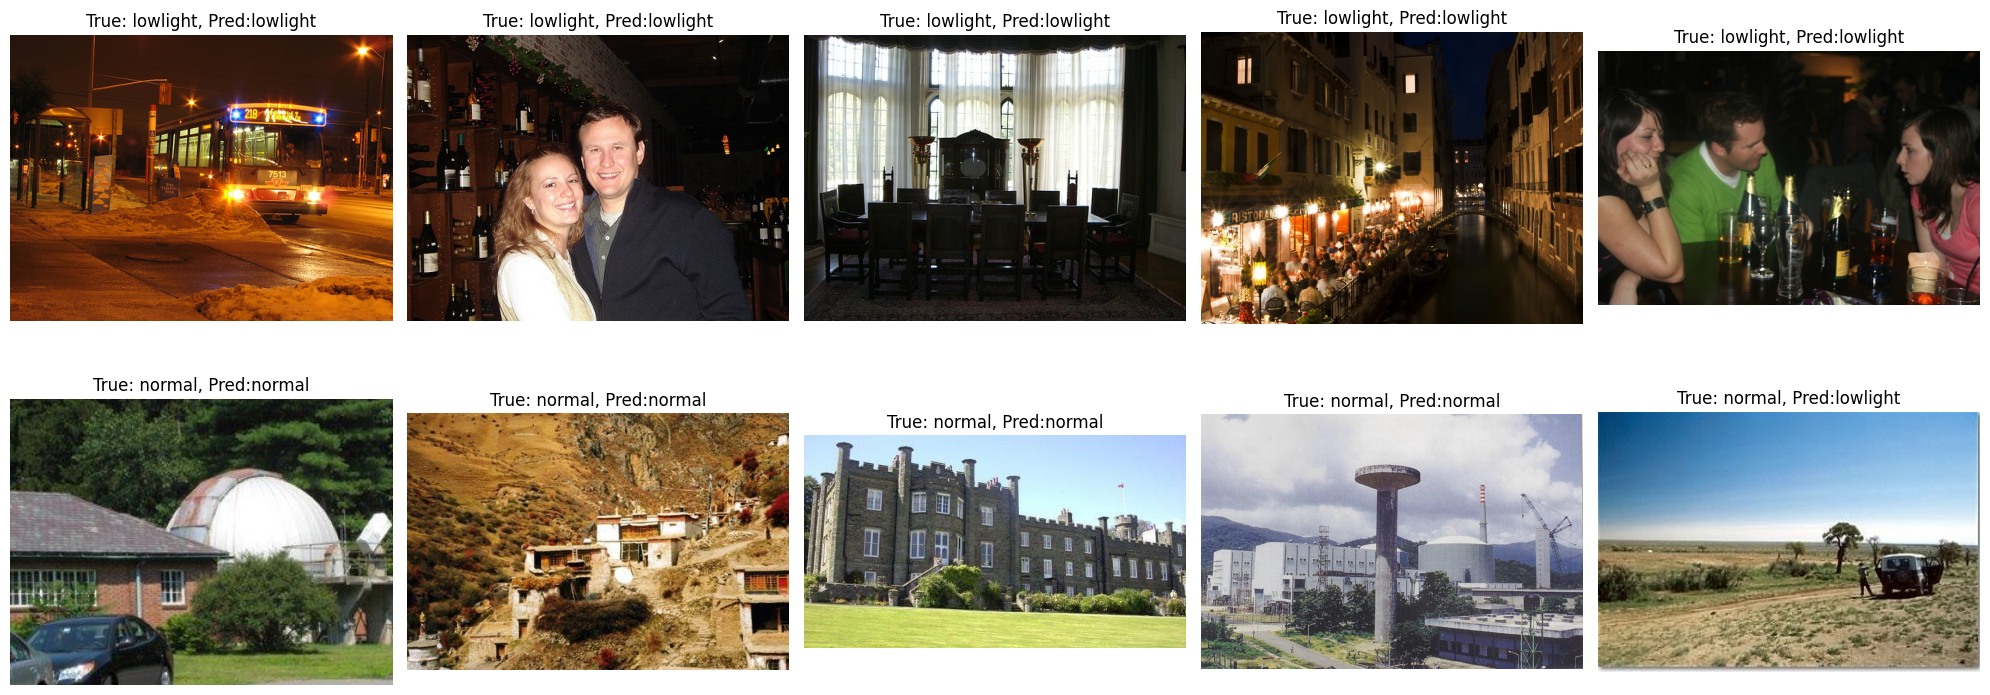

In [34]:
# 클래스별 폴더 경로
class_folder = {
    'lowlight': '/content/brightness_dataset/5/test/lowlight',
    'normal': '/content/brightness_dataset/5/test/normal'
}

plt.figure(figsize=(20,8))
counter = 1

# 각 클래스별로 5장의 이미지 추론 및 시각화
for class_name, folder_path in class_folder.items():
    # 해당 클래스의 이미지 경로 가져오기
    image_paths = glob.glob(os.path.join(folder_path, '*'))
    selected_paths = image_paths[:5]

    for image_path in selected_paths:
      image = load_and_transform_image(image_path, pytorch_transforms)

      net.eval() # 모델을 평가 모드로 설정
      # 모델을 사용한 추론
      with torch.no_grad():
        outputs = net(image)
        probabilities = F.softmax(outputs, dim=1) # 로짓 값을 확률로 변환
        _, predicted = torch.max(probabilities, 1) # 확률로 변환한 값 활용하여 Binary Classification 수행
      prediction = 'lowlight' if predicted.item() == 0 else 'normal'

      # 결과 시각화
      plt.subplot(2, 5, counter)
      plt.imshow(Image.open(image_path))
      plt.title(f'True: {class_name}, Pred:{prediction}')
      plt.axis('off')

      counter += 1

plt.tight_layout()
plt.show()